# Аналіз даних та прогнозування відтоку клієнтів
## Телекомунікаційна компанія

Цей ноутбук містить:
1. Дослідницький аналіз даних (EDA)
2. Візуалізацію розподілів
3. Кореляційний аналіз
4. Підготовку даних для моделювання
5. Навчання та оцінку моделей

In [2]:
# Базові бібліотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Налаштування візуалізації
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

# Машинне навчання
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.metrics import classification_report

# Бібліотеки для градієнтного бустингу
import xgboost as xgb
import lightgbm as lgb


## 2. Завантаження даних

In [3]:
# Завантаження даних
df = pd.read_csv('../data/raw/internet_service_churn.csv', na_values=['', ' ', 'NA', 'null', 'NULL'])
print(f"Розмір даних: {df.shape}")
df.head()

Розмір даних: (72274, 11)


,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0
1,18,0,0,8.22,0,NaN,0,0.0,0.0,0,1
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1
3,27,0,0,6.87,21,NaN,1,0.0,0.0,0,1
4,34,0,0,6.39,0,NaN,0,0.0,0.0,0,1


In [4]:
# Основна інформація про дані
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72274 entries, 0 to 72273
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           72274 non-null  int64  
 1   is_tv_subscriber             72274 non-null  int64  
 2   is_movie_package_subscriber  72274 non-null  int64  
 3   subscription_age             72274 non-null  float64
 4   bill_avg                     72274 non-null  int64  
 5   reamining_contract           50702 non-null  float64
 6   service_failure_count        72274 non-null  int64  
 7   download_avg                 71893 non-null  float64
 8   upload_avg                   71893 non-null  float64
 9   download_over_limit          72274 non-null  int64  
 10  churn                        72274 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 6.1 MB


## 3. Дослідницький аналіз даних(EDA)

In [5]:
# Перевірка пропусків
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})
missing_df[missing_df['Missing Values'] > 0].sort_values('Missing Values', ascending=False)

,Missing Values,Percentage (%)
reamining_contract,21572,29.847525
download_avg,381,0.527161
upload_avg,381,0.527161


<Figure size 1000x600 with 0 Axes>

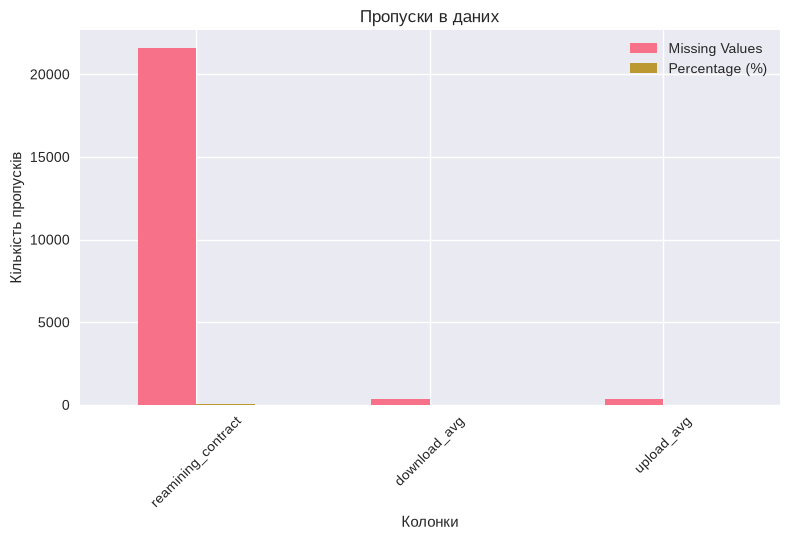

In [6]:
# Візуалізація пропусків
plt.figure(figsize=(10, 6))
missing_df[missing_df['Missing Values'] > 0].plot(kind='bar')
plt.title('Пропуски в даних')
plt.xlabel('Колонки')
plt.ylabel('Кількість пропусків')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.2 Розподіл цільової змінної

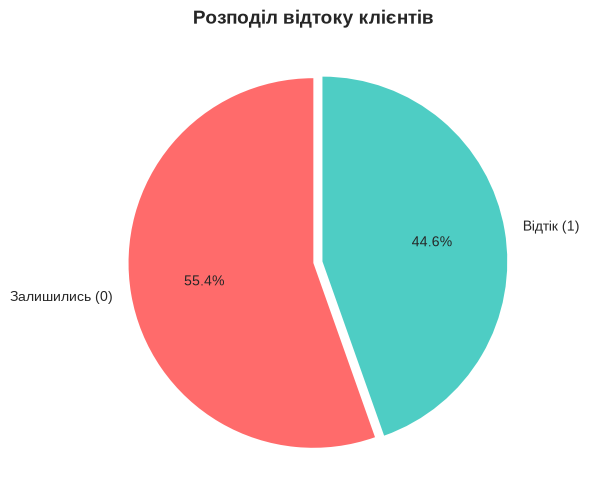


Кількість клієнтів з відтоком: 40050
Кількість клієнтів без відтоку: 32224
Рівень відтоку: 55.41%


In [7]:
# Розподіл churn
plt.figure(figsize=(8, 6))
churn_counts = df['churn'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']
plt.pie(churn_counts.values, labels=['Залишились (0)', 'Відтік (1)'], 
        autopct='%1.1f%%', colors=colors, startangle=90, explode=(0, 0.05))
plt.title('Розподіл відтоку клієнтів', fontsize=14, fontweight='bold')
plt.show()

print(f"\nКількість клієнтів з відтоком: {df['churn'].sum()}")
print(f"Кількість клієнтів без відтоку: {len(df) - df['churn'].sum()}")
print(f"Рівень відтоку: {df['churn'].mean()*100:.2f}%")

### 3.3 Розподіл числових ознак

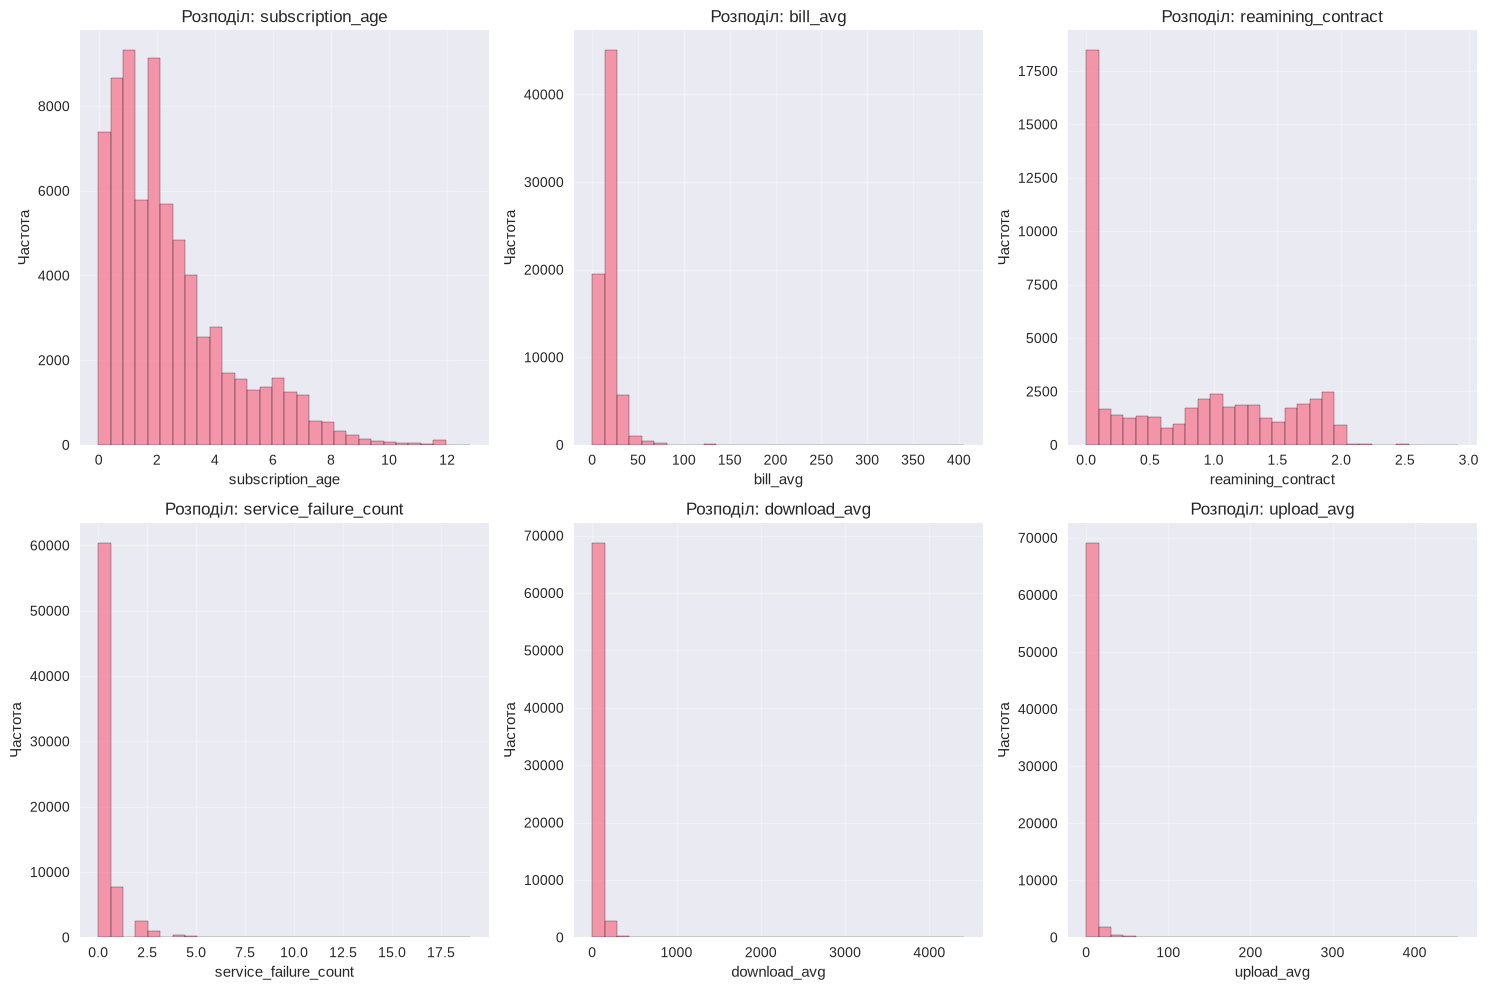

In [8]:
# Гістограми числових ознак
numeric_cols = ['subscription_age', 'bill_avg', 'reamining_contract', 
                'service_failure_count', 'download_avg', 'upload_avg']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Розподіл: {col}', fontsize=12)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Частота')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.4 Аналіз категоріальних ознак

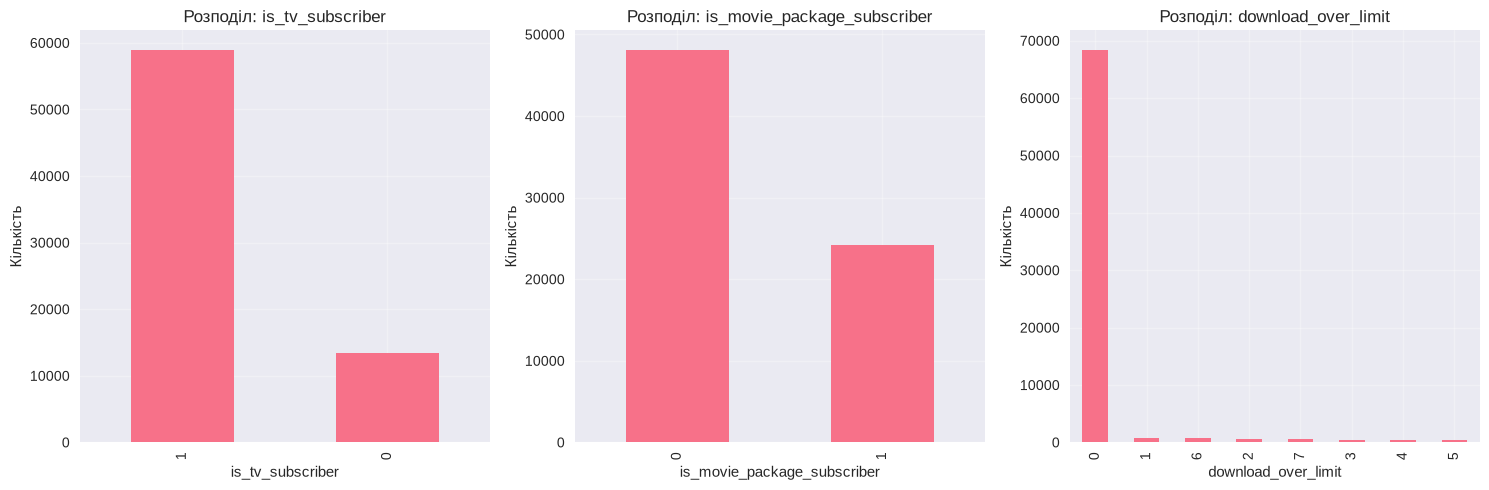

In [9]:
# Категоріальні ознаки
cat_cols = ['is_tv_subscriber', 'is_movie_package_subscriber', 'download_over_limit']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.ravel()

for idx, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[idx])
    axes[idx].set_title(f'Розподіл: {col}', fontsize=12)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Кількість')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.5 Аналіз відтоку за категоріальними ознаками

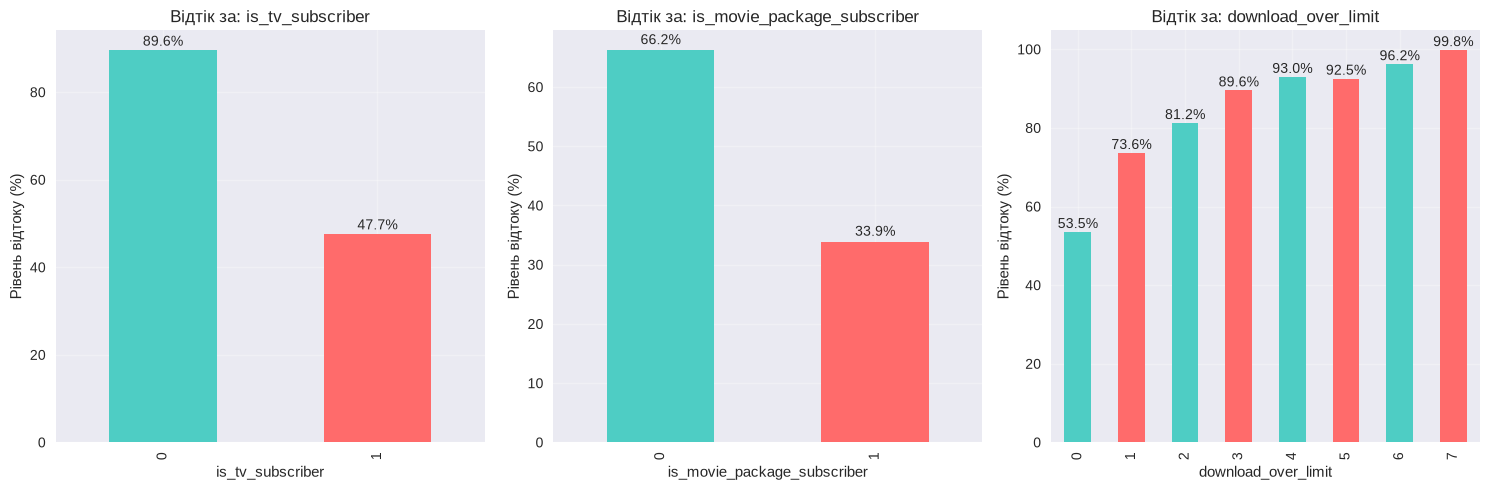

In [10]:
# Відтік за категоріальними ознаками
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.ravel()

for idx, col in enumerate(cat_cols):
    churn_by_cat = df.groupby(col)['churn'].mean() * 100
    churn_by_cat.plot(kind='bar', ax=axes[idx], color=['#4ECDC4', '#FF6B6B'])
    axes[idx].set_title(f'Відтік за: {col}', fontsize=12)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Рівень відтоку (%)')
    axes[idx].grid(True, alpha=0.3)
    for i, v in enumerate(churn_by_cat):
        axes[idx].text(i, v + 1, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

### 3.6 Кореляційний аналіз

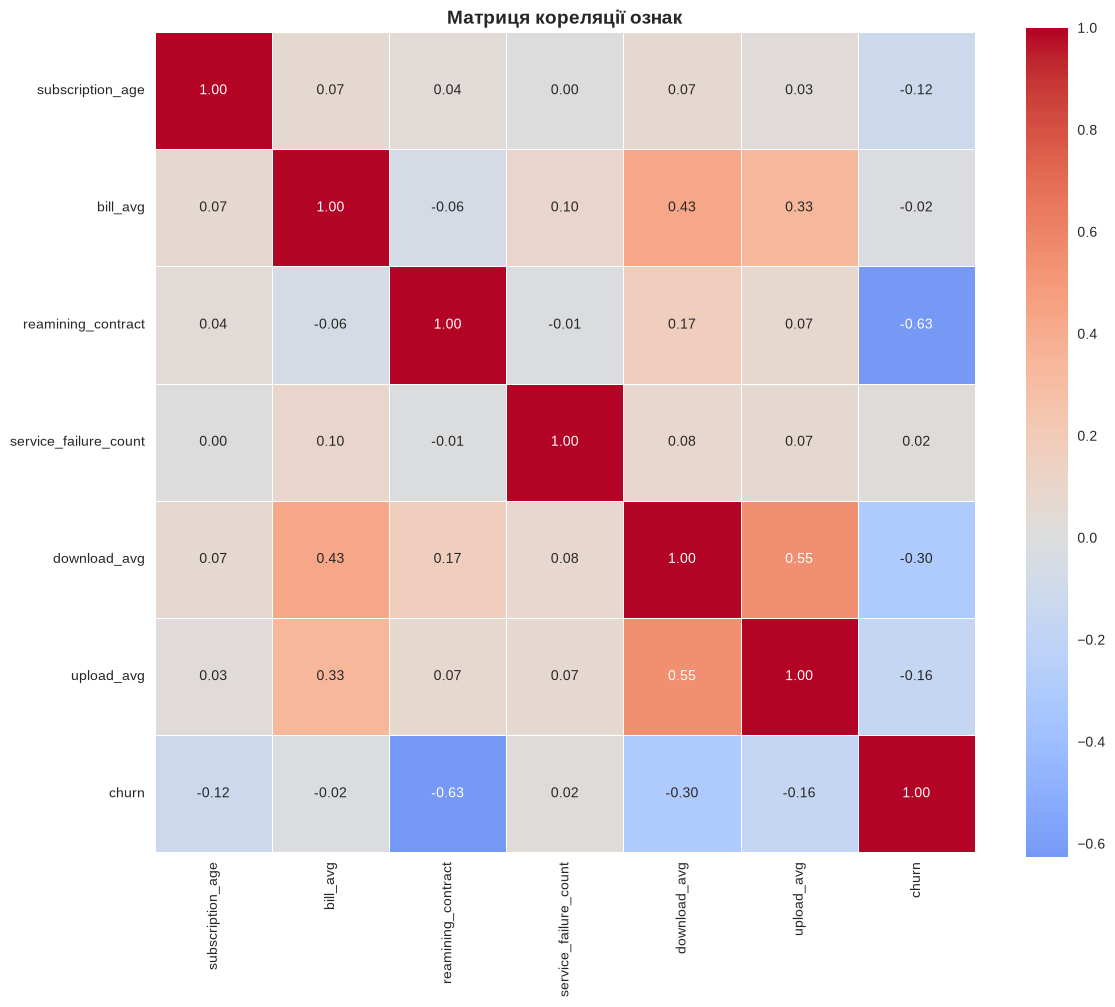

In [11]:
# Матриця кореляції
plt.figure(figsize=(12, 10))
corr_matrix = df[numeric_cols + ['churn']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=0.5)
plt.title('Матриця кореляції ознак', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

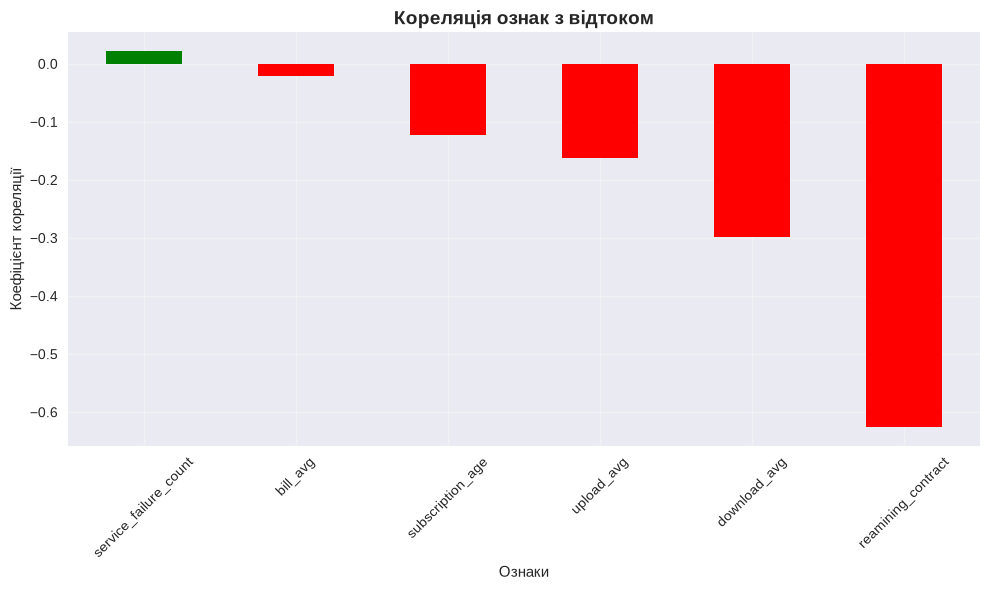

In [12]:
# Кореляція з цільовою змінною
churn_corr = df[numeric_cols + ['churn']].corr()['churn'].sort_values(ascending=False)
churn_corr = churn_corr[churn_corr.index != 'churn']

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in churn_corr.values]
churn_corr.plot(kind='bar', color=colors)
plt.title('Кореляція ознак з відтоком', fontsize=14, fontweight='bold')
plt.xlabel('Ознаки')
plt.ylabel('Коефіцієнт кореляції')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.7 Аналіз відтоку за числовими ознаками

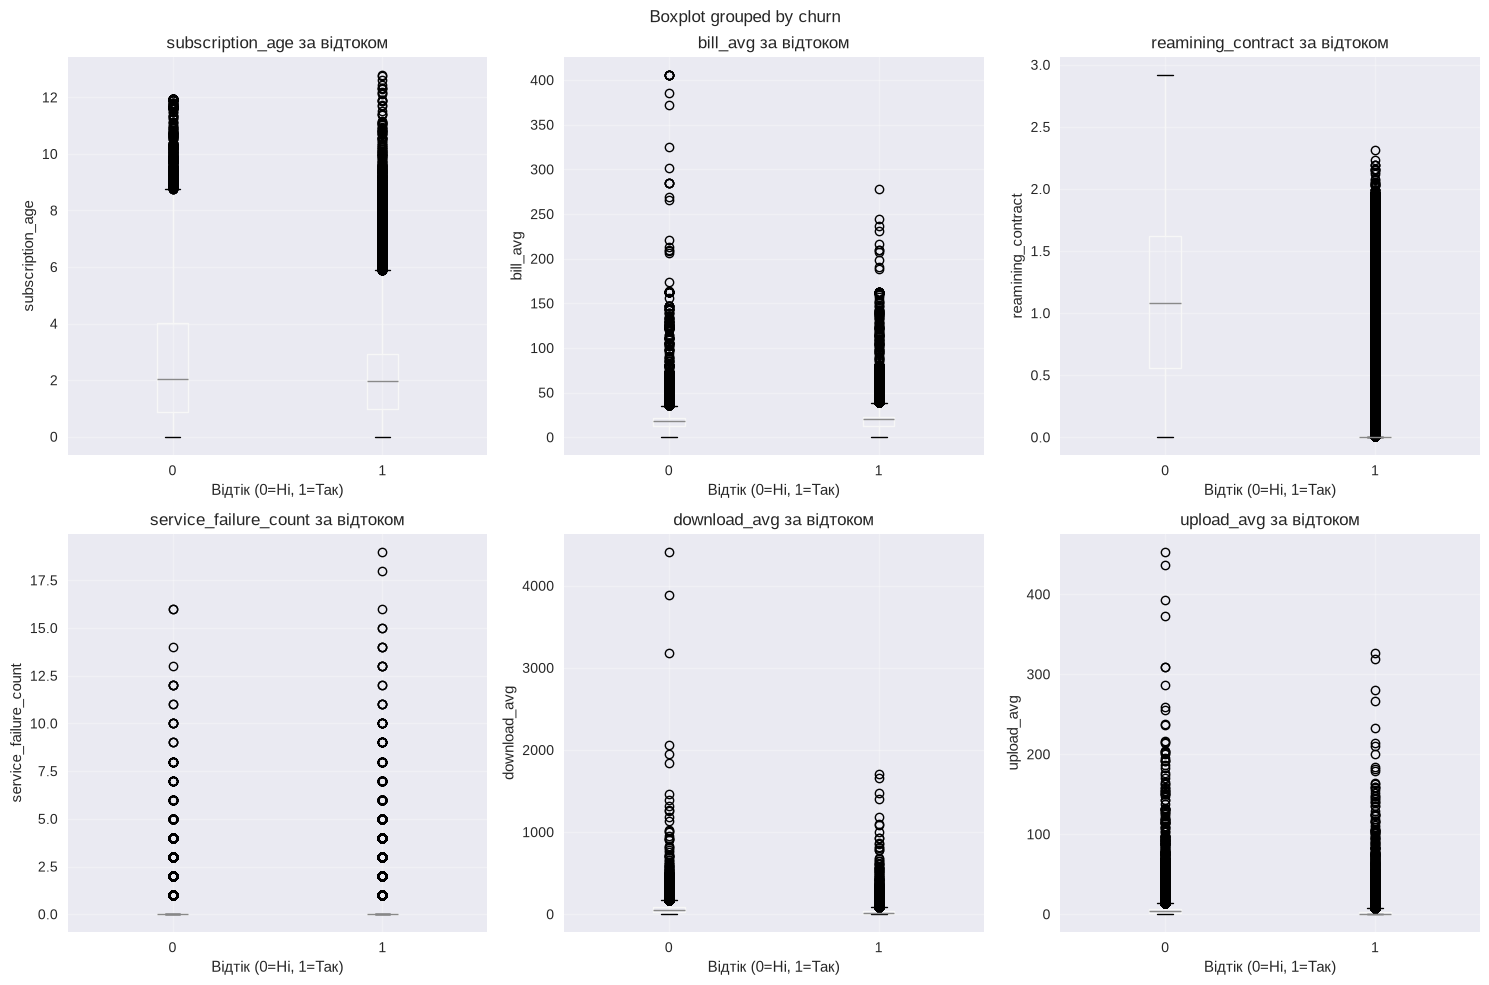

In [13]:
# Box plots для числових ознак
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    df.boxplot(column=col, by='churn', ax=axes[idx])
    axes[idx].set_title(f'{col} за відтоком', fontsize=12)
    axes[idx].set_xlabel('Відтік (0=Ні, 1=Так)')
    axes[idx].set_ylabel(col)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Підготовка даних для моделювання

In [14]:
# Копіювання даних
df_processed = df.copy()

# Видалення колонки id
df_processed = df_processed.drop('id', axis=1)

# Обробка пропусків
df_processed['reamining_contract_missing'] = df_processed['reamining_contract'].isnull().astype(int)
df_processed['reamining_contract'] = df_processed['reamining_contract'].fillna(df_processed['reamining_contract'].median())
df_processed['download_avg'] = df_processed['download_avg'].fillna(df_processed['download_avg'].median())
df_processed['upload_avg'] = df_processed['upload_avg'].fillna(df_processed['upload_avg'].median())

print("Пропуски після обробки:")
print(df_processed.isnull().sum())

Пропуски після обробки:
is_tv_subscriber               0
is_movie_package_subscriber    0
subscription_age               0
bill_avg                       0
reamining_contract             0
service_failure_count          0
download_avg                   0
upload_avg                     0
download_over_limit            0
churn                          0
reamining_contract_missing     0
dtype: int64


In [15]:
# Кодування категоріальних змінних
le = LabelEncoder()
cat_cols = ['is_tv_subscriber', 'is_movie_package_subscriber', 'download_over_limit']

for col in cat_cols:
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))

print("Дані після кодування:")
df_processed.head()

Дані після кодування:


,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn,reamining_contract_missing
0,1,0,11.95,25,0.14,0,8.4,2.3,0,0,0
1,0,0,8.22,0,0.57,0,0.0,0.0,0,1,1
2,1,0,8.91,16,0.00,0,13.7,0.9,0,1,0
3,0,0,6.87,21,0.57,1,0.0,0.0,0,1,1
4,0,0,6.39,0,0.57,0,0.0,0.0,0,1,1


In [16]:
# Розділення на ознаки та ціль
X = df_processed.drop('churn', axis=1)
y = df_processed['churn']

# Нормалізація
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Ознаки: {X.shape[1]}")
print(f"Зразки: {X.shape[0]}")

Ознаки: 10
Зразки: 72274


In [17]:
# Розділення на тренувальний та тестовий набори
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Тренувальний набір: {X_train.shape[0]} зразків")
print(f"Тестовий набір: {X_test.shape[0]} зразків")
print(f"\nРозподіл в тренуванні:")
print(f"  Відтік: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"  Без відтоку: {len(y_train) - y_train.sum()} ({(1-y_train.mean())*100:.1f}%)")
print(f"\nРозподіл в тесті:")
print(f"  Відтік: {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print(f"  Без відтоку: {len(y_test) - y_test.sum()} ({(1-y_test.mean())*100:.1f}%)")

Тренувальний набір: 57819 зразків
Тестовий набір: 14455 зразків

Розподіл в тренуванні:
  Відтік: 32040 (55.4%)
  Без відтоку: 25779 (44.6%)

Розподіл в тесті:
  Відтік: 8010 (55.4%)
  Без відтоку: 6445 (44.6%)


## 5. Навчання моделей

In [18]:
# Функція для оцінки моделі
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }
    
    return metrics, y_pred, y_pred_proba

In [19]:
# Список моделей
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
}

# Навчання та оцінка
results = []

for name, model in models.items():
    print(f"Навчання: {name}...")
    model.fit(X_train, y_train)
    metrics, y_pred, y_pred_proba = evaluate_model(model, X_test, y_test, name)
    results.append(metrics)
    print(f"  Accuracy: {metrics['Accuracy']:.4f}")
    print(f"  ROC-AUC: {metrics['ROC-AUC']:.4f}")
    print()

Навчання: Logistic Regression...
  Accuracy: 0.8764
  ROC-AUC: 0.9310

Навчання: Random Forest...
  Accuracy: 0.9411
  ROC-AUC: 0.9810

Навчання: Gradient Boosting...
  Accuracy: 0.9367
  ROC-AUC: 0.9740

Навчання: XGBoost...
  Accuracy: 0.9438
  ROC-AUC: 0.9826

Навчання: LightGBM...
  Accuracy: 0.9415
  ROC-AUC: 0.9817



In [20]:
# Порівняння моделей
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('ROC-AUC', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,XGBoost,0.943826,0.956378,0.941573,0.948918,0.982561
4,LightGBM,0.941474,0.956073,0.937453,0.946672,0.981663
1,Random Forest,0.941058,0.957088,0.935581,0.946212,0.980974
2,Gradient Boosting,0.936700,0.954866,0.929713,0.942122,0.973960
0,Logistic Regression,0.876375,0.874744,0.906742,0.890455,0.930982


### 5.1 Візуалізація порівняння моделей

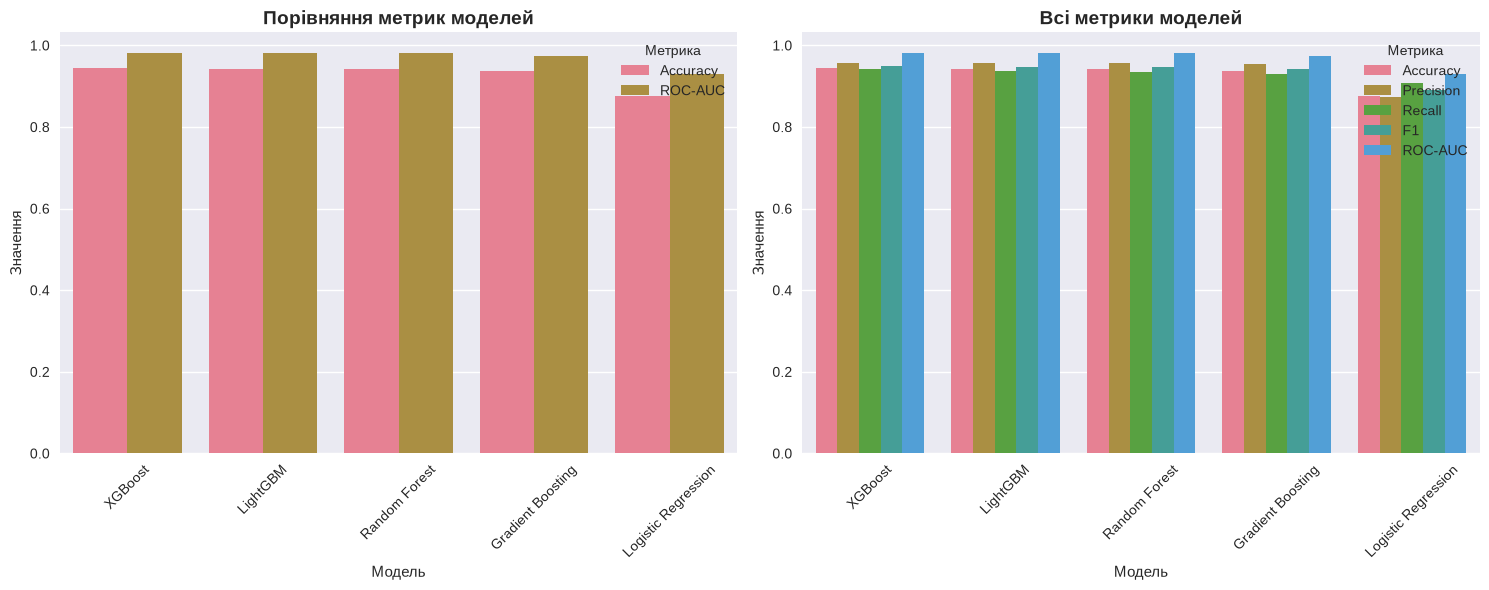

In [21]:
# Порівняння метрик
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Точність та ROC-AUC
results_df_melted = results_df.melt(id_vars=['Model'], value_vars=['Accuracy', 'ROC-AUC'])
sns.barplot(data=results_df_melted, x='Model', y='value', hue='variable', ax=axes[0])
axes[0].set_title('Порівняння метрик моделей', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Значення')
axes[0].set_xlabel('Модель')
axes[0].legend(title='Метрика')
axes[0].tick_params(axis='x', rotation=45)

# Всі метрики
results_df_melted_all = results_df.melt(id_vars=['Model'], 
                                       value_vars=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'])
sns.barplot(data=results_df_melted_all, x='Model', y='value', hue='variable', ax=axes[1])
axes[1].set_title('Всі метрики моделей', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Значення')
axes[1].set_xlabel('Модель')
axes[1].legend(title='Метрика')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Аналіз найкращої моделі

In [22]:
# Вибір найкращої моделі
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"Найкраща модель: {best_model_name}")
print(f"Точність: {results_df.iloc[0]['Accuracy']:.4f}")
print(f"ROC-AUC: {results_df.iloc[0]['ROC-AUC']:.4f}")

Найкраща модель: XGBoost
Точність: 0.9438
ROC-AUC: 0.9826


In [23]:
 # Передбачення для найкращої моделі
y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

### 6.1 Матриця плутанини

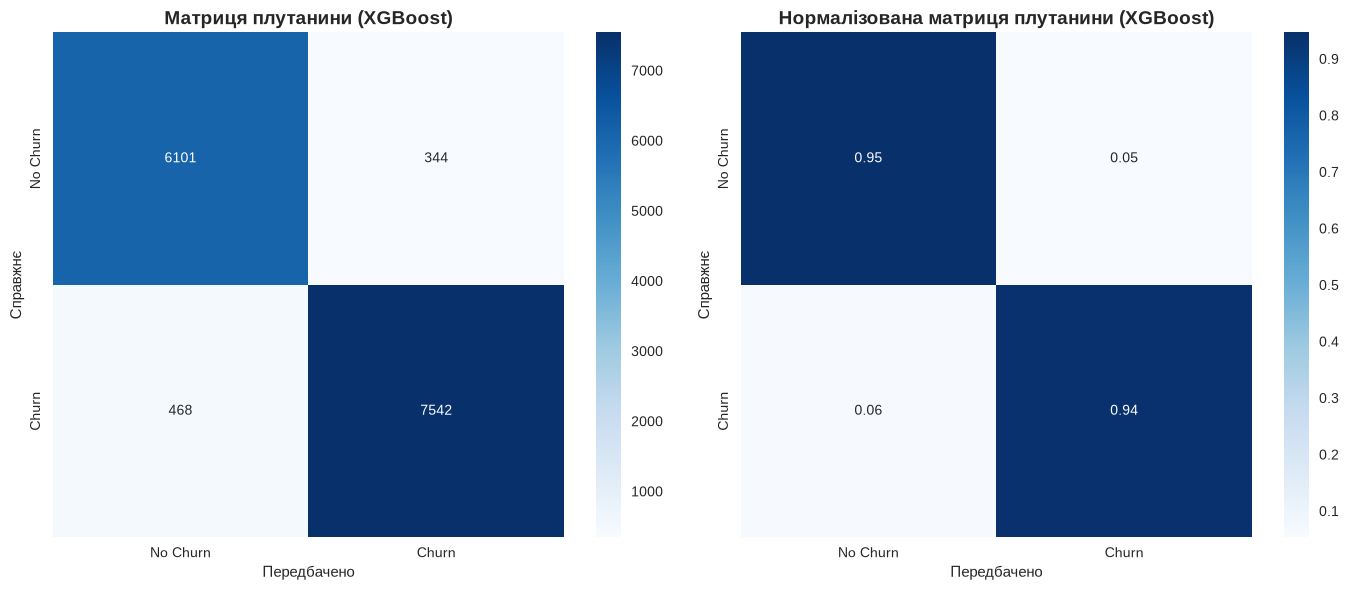

In [24]:
# Матриця плутанини
cm = confusion_matrix(y_test, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Матриця плутанини
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Матриця плутанини ({best_model_name})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Передбачено')
axes[0].set_ylabel('Справжнє')
axes[0].set_xticklabels(['No Churn', 'Churn'])
axes[0].set_yticklabels(['No Churn', 'Churn'])

# Нормалізована матриця плутанини
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1])
axes[1].set_title(f'Нормалізована матриця плутанини ({best_model_name})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Передбачено')
axes[1].set_ylabel('Справжнє')
axes[1].set_xticklabels(['No Churn', 'Churn'])
axes[1].set_yticklabels(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

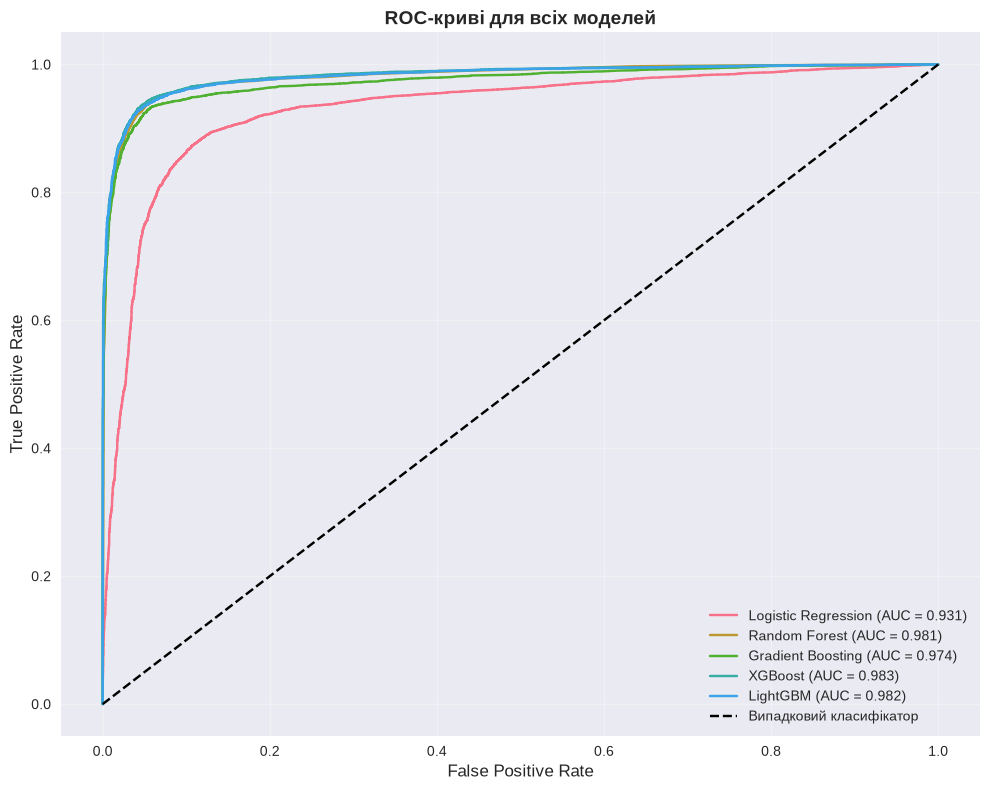

In [25]:
# ROC-крива
plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Випадковий класифікатор')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-криві для всіх моделей', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 Важливість ознак

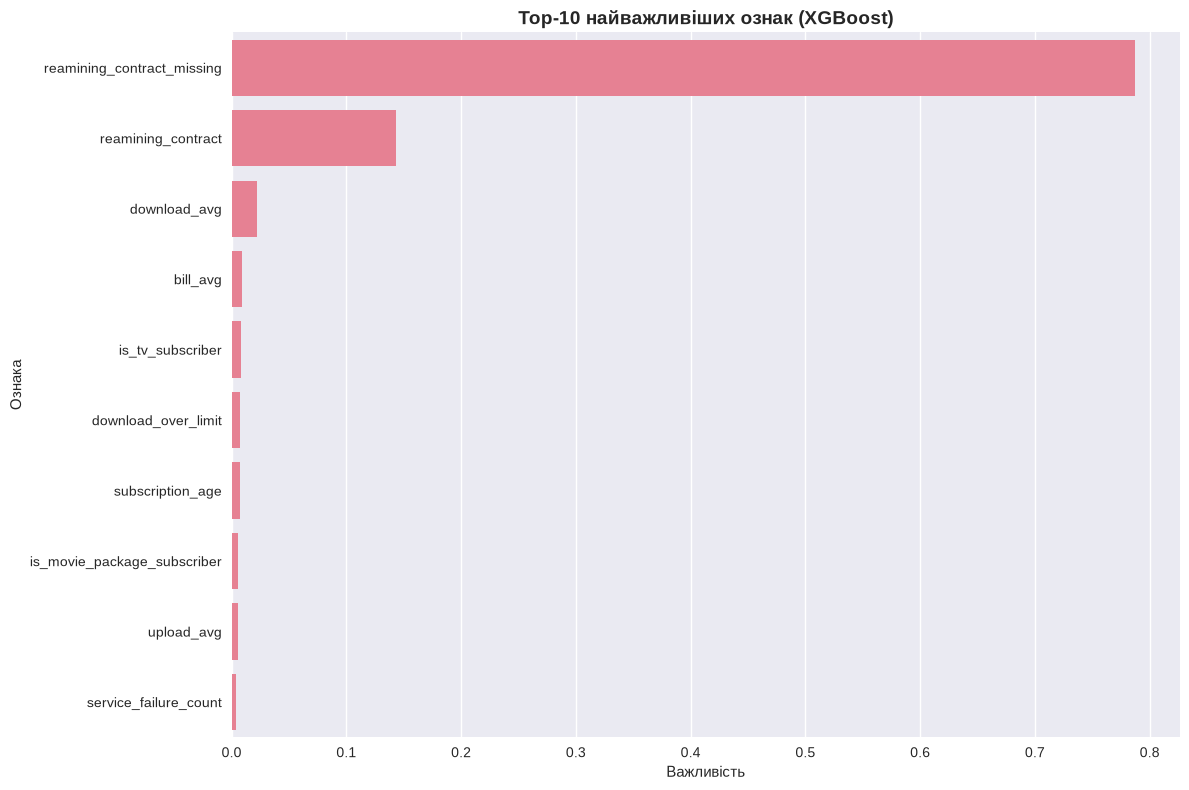


Топ-5 найважливіших ознак:
  reamining_contract_missing: 0.787
  reamining_contract: 0.144
  download_avg: 0.022
  bill_avg: 0.009
  is_tv_subscriber: 0.008


In [26]:
# Важливість ознак для найкращої моделі
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature')
    plt.title(f'Top-10 найважливіших ознак ({best_model_name})', fontsize=14, fontweight='bold')
    plt.xlabel('Важливість')
    plt.ylabel('Ознака')
    plt.tight_layout()
    plt.show()
    
    print("\nТоп-5 найважливіших ознак:")
    for _, row in feature_importance.head(5).iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.3f}")

### 6.4 Класифікаційний звіт

In [27]:
print("Класифікаційний звіт для найкращої моделі:")
print("=" * 50)
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

Класифікаційний звіт для найкращої моделі:
              precision    recall  f1-score   support

    No Churn       0.93      0.95      0.94      6445
       Churn       0.96      0.94      0.95      8010

    accuracy                           0.94     14455
   macro avg       0.94      0.94      0.94     14455
weighted avg       0.94      0.94      0.94     14455



## 7. Висновки

1. **Дані**: 72,274 клієнтів, 55.4% з відтоком
2. **Найважливіші ознаки**: bill_avg, subscription_age, reamining_contract
3. **Найкраща модель**: XGBoost з точністю Accuracy 94.38% та ROC-AUC 0.983
4. **Основні висновки**:
   - модель добре розрізняє клієнтів з високим і низьким ризиком відтоку;
   - ознаки, пов’язані з тривалістю підписки та станом контракту, мають сильний вплив на прогноз;
   - фінансові характеристики також відіграють важливу роль у визначенні ризику відтоку.
5. **Рекомендації**:
   - зосередити увагу на клієнтах з високим ризиком відтоку, особливо тих, хто має коротший термін підписки або незручні умови контракту;
   - розробити превентивні заходи для клієнтів із підвищеним ризиком, зокрема персоналізовані пропозиції або підтримку.;
   - Спеціальні пропозиції для клієнтів з високим ризиком;
   - використовувати XGBoost як основну модель для прогнозування відтоку.
   